# **Estudio Estadístico de la Degradación SNR — Notebook didáctico**

Este notebook reproduce el flujo de `main.py` y desarrolla en detalle el análisis estadístico que respalda la **Tabla 4.1** del manuscrito de tesis.

**Alcance del estudio:**
- Carga directa de los **9 archivos** del estudio desde el repositorio público (no requiere clonar).
- Visualizaciones (violín, histograma, scatter) y tabla de estadísticas descriptivas con glosario didáctico de cada columna.
- Análisis inferencial: prueba de **normalidad (Shapiro–Wilk)** y prueba de **comparación entre grupos (Kruskal–Wallis)**, con explicación detallada de las hipótesis nulas y su interpretación.
- Justificación bibliográfica de la cadena estadística usando el árbol de decisión de **Marusteri & Bacarea (2010)**.

**Salida:** todas las figuras se guardan en `Study_images/` (PNG y PDF a 600 dpi) y la tabla de estadísticas se exporta como `statistics.csv`.

Ejecutar las celdas en orden de arriba hacia abajo.

## 0. Instalación de dependencias

En Colab la mayoría ya están preinstaladas; este bloque garantiza versiones compatibles.

In [1]:
!pip install -q pandas numpy matplotlib seaborn scipy scikit-learn openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports y carpeta de salida `Study_images/`

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from sklearn.preprocessing import RobustScaler

# Carpeta donde se guardarán todas las figuras y la tabla de estadísticas
images_path = os.path.join(os.getcwd(), 'Study_images')
os.makedirs(images_path, exist_ok=True)
print(f'Carpeta de salida: {images_path}')

Carpeta de salida: c:\Users\Administrador\Documents\SNR-Lab\Study_images


## 2. Carga de datos desde GitHub

Los **9 archivos** del estudio se leen directamente desde la rama `main` del repositorio `SNR-Lab` mediante URLs `raw`, por lo que el notebook funciona en Colab sin clonar el repositorio.

> **Alcance:** los 9 escenarios reportados son **Antena Yagi (Piso 4 outdoor)**, **Pisos 1–5**, **Sótanos 1 y 2**, y banco **RF–VLC**. La antena Yagi se ubica en la zona al aire libre del Piso 4 (no en la terraza del 6º piso), elegida deliberadamente porque está justo encima de los sótanos, lo que permite tender un cable vertical hasta Sótano 2 emulando un trayecto outdoor → indoor profundo.

In [3]:
# URL base del repositorio (carpeta Data/ en GitHub)
base_url = 'https://raw.githubusercontent.com/Navarrojuan212/SNR-Lab/main/Data/'

# Archivos a cargar (los 9 escenarios de la Tabla 4.1)
file_names = [
    'Piso1_103_5MHz_SNR.xlsx',
    'Piso2_103_5MHz_SNR.xlsx',
    'Piso3_103_5MHz_SNR.xlsx',
    'Piso4_103_5MHz_SNR.xlsx',
    'Piso5_103_5MHz_SNR.xlsx',
    'AntennaOutdoor_103_5MHz_SNR.xlsx',
    'RF-VLC_SNR.xlsx',
    'Sotano1_103_5MHz_SNR_B.csv',
    'Sotano2_103_5MHz_SNR_E.csv'
]

# Traducción a nombres amigables (replica main.py)
def translate_name(file_name):
    mapping = {
        'Piso1_103_5MHz_SNR.xlsx': 'Piso 1',
        'Piso2_103_5MHz_SNR.xlsx': 'Piso 2',
        'Piso3_103_5MHz_SNR.xlsx': 'Piso 3',
        'Piso4_103_5MHz_SNR.xlsx': 'Piso 4',
        'Piso5_103_5MHz_SNR.xlsx': 'Piso 5',
        'AntennaOutdoor_103_5MHz_SNR.xlsx': 'Antena',
        'RF-VLC_SNR.xlsx': 'RF - VLC',
        'Sotano1_103_5MHz_SNR_B.csv': 'Sótano 1',
        'Sotano2_103_5MHz_SNR_E.csv': 'Sótano 2'
    }
    return mapping.get(file_name, 'Unknown Source')

# Lectura de CSV o Excel según extensión
def load_data(file_url):
    if file_url.endswith('.csv'):
        return pd.read_csv(file_url)
    elif file_url.endswith('.xlsx'):
        return pd.read_excel(file_url, engine='openpyxl')
    else:
        raise ValueError(f'Unsupported file type: {file_url}')

In [4]:
# Cargar todos los archivos en un diccionario de DataFrames
data_frames = {}
for file_name in file_names:
    file_url = base_url + file_name
    try:
        df = load_data(file_url)
        df['Source'] = translate_name(file_name)             # Nombre amigable
        df['Time_Index'] = np.arange(0, len(df) * 0.1, 0.1)  # Eje temporal sintético (0.1 s)
        data_frames[file_name] = df
        print(f'Loaded {file_name} -> {len(df)} filas')
    except Exception as e:
        print(f'Error al procesar {file_name}: {e}')

Loaded Piso1_103_5MHz_SNR.xlsx -> 200 filas
Loaded Piso2_103_5MHz_SNR.xlsx -> 200 filas
Loaded Piso3_103_5MHz_SNR.xlsx -> 200 filas
Loaded Piso4_103_5MHz_SNR.xlsx -> 200 filas
Loaded Piso5_103_5MHz_SNR.xlsx -> 200 filas
Loaded AntennaOutdoor_103_5MHz_SNR.xlsx -> 200 filas
Loaded RF-VLC_SNR.xlsx -> 200 filas
Loaded Sotano1_103_5MHz_SNR_B.csv -> 200 filas
Loaded Sotano2_103_5MHz_SNR_E.csv -> 200 filas


In [5]:
# Verificación de tamaños y construcción del DataFrame combinado
for file_name, df in data_frames.items():
    print(f'{translate_name(file_name)}: {len(df)} filas')

combined_df = pd.concat(data_frames.values(), ignore_index=True)
print('\nForma de combined_df:', combined_df.shape)
combined_df.head()

Piso 1: 200 filas
Piso 2: 200 filas
Piso 3: 200 filas
Piso 4: 200 filas
Piso 5: 200 filas
Antena: 200 filas
RF - VLC: 200 filas
Sótano 1: 200 filas
Sótano 2: 200 filas

Forma de combined_df: (1800, 7)


,Timestamp,Frequency,SNR,Peak,Floor,Source,Time_Index
0,2024-03-22 16:01:42.631000,103500000,25.16,-25.49,-50.65,Piso 1,0.0
1,2024-03-22 16:01:42.737000,103500000,25.29,-25.56,-50.84,Piso 1,0.1
2,2024-03-22 16:01:42.844000,103500000,24.77,-25.71,-50.48,Piso 1,0.2
3,2024-03-22 16:01:42.955000,103500000,24.49,-25.90,-50.40,Piso 1,0.3
4,2024-03-22 16:01:43.061000,103500000,24.14,-26.11,-50.25,Piso 1,0.4


## 3. Violin Plot por ubicación

Distribución de SNR por ubicación con boxplot interno y outliers (regla 1.5·IQR) marcados en rojo.

C:\Users\Administrador\AppData\Local\Temp\ipykernel_17424\1646433826.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


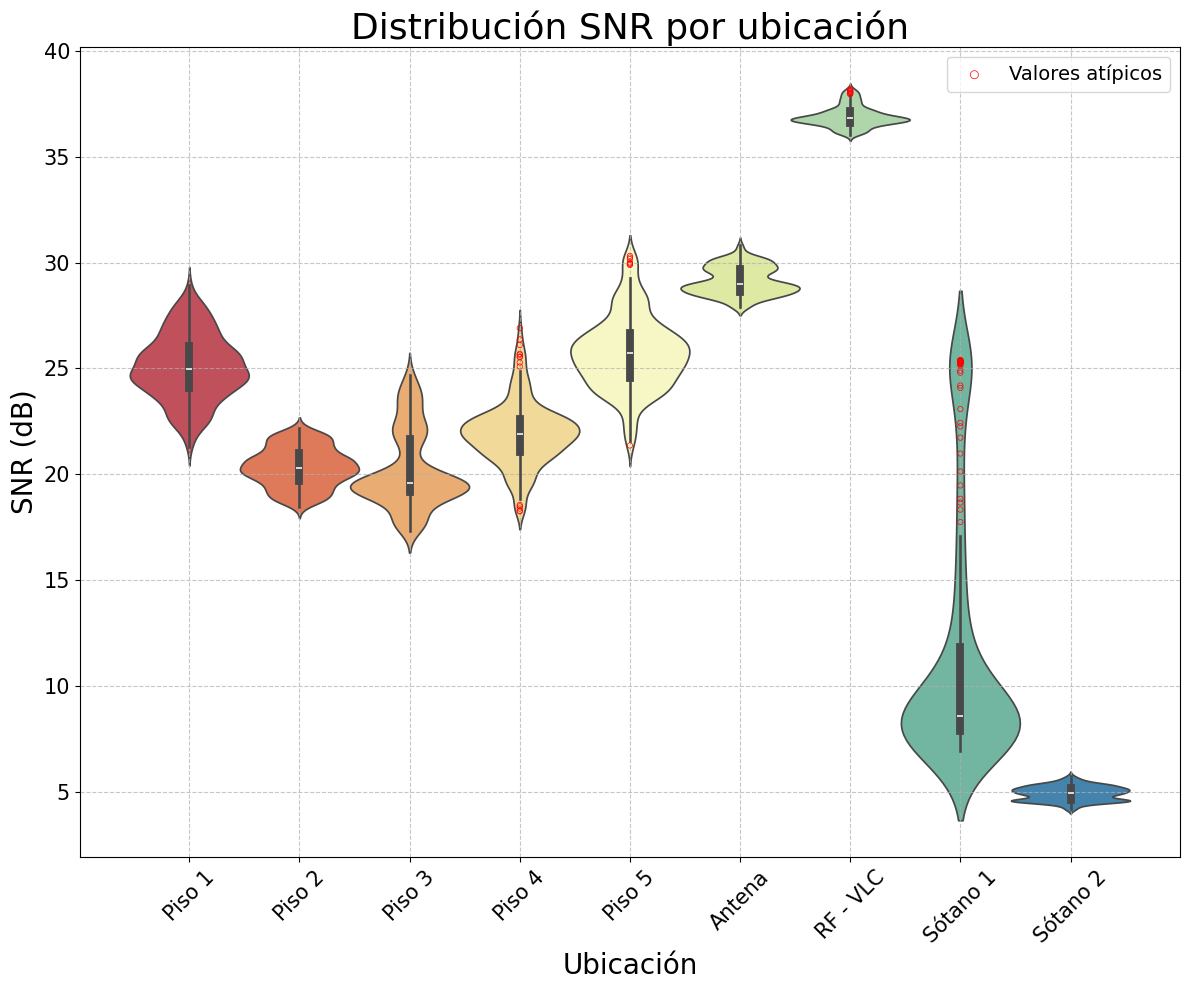

In [6]:
# Outliers por grupo usando IQR
def calculate_outliers(data, group_column, value_column):
    grouped_outliers = {}
    for group_name, group_data in data.groupby(group_column):
        q1 = group_data[value_column].quantile(0.25)
        q3 = group_data[value_column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = group_data[(group_data[value_column] < lower_bound) | (group_data[value_column] > upper_bound)]
        grouped_outliers[group_name] = outliers[value_column]
    return grouped_outliers

def create_violin_plot(combined_df, images_path):
    plt.figure(figsize=(12, 10))
    unique_sources = combined_df['Source'].unique()
    palette = sns.color_palette('Spectral', len(unique_sources))
    sns.violinplot(
        data=combined_df,
        x='Source',
        y='SNR',
        palette=palette,
        inner='box',
        width=1.8,
        gap=0.4,
        bw_adjust=0.8,
    )

    outliers = calculate_outliers(combined_df, 'Source', 'SNR')
    for source, outlier_values in outliers.items():
        x_position = list(unique_sources).index(source)
        plt.scatter(
            [x_position] * len(outlier_values),
            outlier_values,
            color='red',
            facecolors='none',
            linewidths=0.5,
            s=15,
            zorder=3,
            label='Valores atípicos' if source == list(outliers.keys())[0] else ''
        )

    plt.legend(loc='upper right', fontsize=14, scatterpoints=1, markerscale=1.5)
    plt.title('Distribución SNR por ubicación', fontsize=26)
    plt.xlabel('Ubicación', fontsize=20)
    plt.ylabel('SNR (dB)', fontsize=20)
    plt.yticks(fontsize=15)
    plt.xticks(rotation=45, fontsize=15)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(images_path, 'violin_plotIET.pdf'), format='pdf', dpi=600, transparent=True)
    plt.savefig(os.path.join(images_path, 'violin_plotIET.png'), format='png', dpi=600, transparent=True)
    plt.show()

create_violin_plot(combined_df, images_path)

## 4. Histograma SNR

Histograma con KDE para todas las ubicaciones superpuestas.

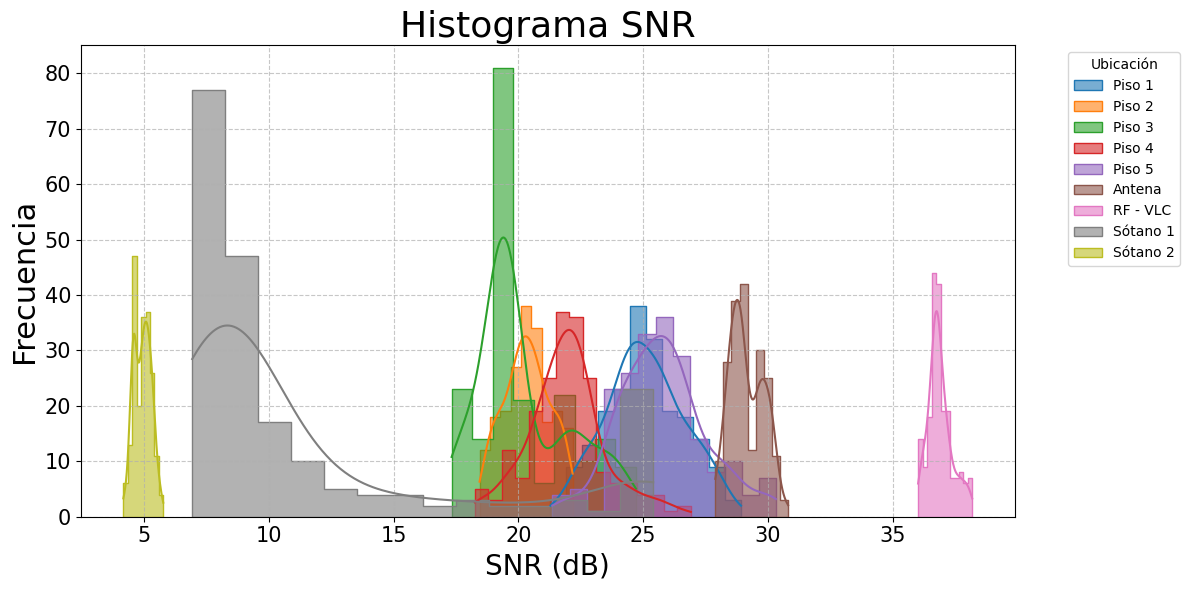

In [7]:
def create_histogram(data_frames, images_path, translate_name):
    plt.figure(figsize=(12, 6))
    for file_name, df in data_frames.items():
        translated_name = translate_name(file_name)
        sns.histplot(df['SNR'], kde=True, element='step', label=translated_name, alpha=0.6)
    plt.title('Histograma SNR', fontsize=26)
    plt.xlabel('SNR (dB)', fontsize=20)
    plt.ylabel('Frecuencia', fontsize=22)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.legend(title='Ubicación', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(images_path, 'histogramIET.pdf'), format='pdf', dpi=600, transparent=True)
    plt.savefig(os.path.join(images_path, 'histogramIET.png'), format='png', dpi=600, transparent=True)
    plt.show()

create_histogram(data_frames, images_path, translate_name)

## 5. Scatter SNR vs Tiempo

Evolución temporal del SNR (índice sintético cada 0.1 s) por ubicación.

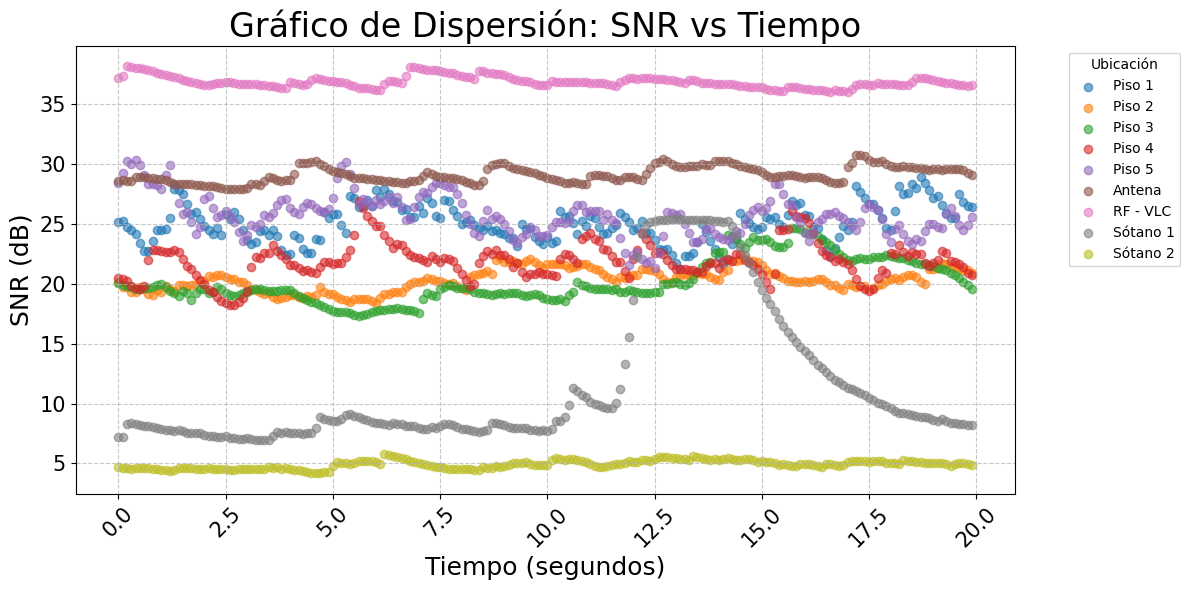

In [8]:
def create_scatterplot(data_frames, images_path, translate_name):
    plt.figure(figsize=(12, 6))
    for file_name, df in data_frames.items():
        translated_name = translate_name(file_name)
        plt.scatter(df['Time_Index'], df['SNR'], label=translated_name, alpha=0.6)
    plt.title('Gráfico de Dispersión: SNR vs Tiempo', fontsize=24)
    plt.xlabel('Tiempo (segundos)', fontsize=18)
    plt.ylabel('SNR (dB)', fontsize=18)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.legend(title='Ubicación', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(images_path, 'scatterplotIET.pdf'), format='pdf', dpi=600, transparent=True)
    plt.savefig(os.path.join(images_path, 'scatterplotIET.png'), format='png', dpi=600, transparent=True)
    plt.show()

create_scatterplot(data_frames, images_path, translate_name)

## 6. Estadísticas descriptivas por ubicación

Para cada uno de los 9 escenarios calculamos un conjunto de **estadísticos descriptivos** del SNR. Cada fila de la tabla corresponde a un escenario y cada columna a un estadístico distinto.

### ¿Qué buscamos en estos números?

Los descriptores se agrupan en dos familias:

- **Tendencia central** (¿dónde "viven" los datos?): media $\bar{x}$, mediana $\tilde{x}$, moda $\hat{x}$.
- **Dispersión** (¿qué tan estables son?): cuartiles $Q_1, Q_3$, IQR, varianza $\sigma^2$, desviación estándar $\sigma$, fronteras de outliers.

> Cuando $\bar{x} \neq \tilde{x}$, la distribución es **asimétrica**: la mediana es más informativa porque es robusta a outliers; la media se desplaza hacia la cola larga.

In [9]:
def calculate_statistics(df):
    stats_dict = {
        'Place': [], 'Q1 {dB}': [], 'Mean {dB}': [], 'Q3 {dB}': [], 'IQR {dB}': [],
        'Lower Outlier {dB}': [], 'Upper Outlier {dB}': [], 'Std Dev {dB}': [],
        'Median {dB}': [], 'Mode {dB}': [], 'Variance {dB}': []
    }
    place = df['Source'].iloc[0] if 'Source' in df.columns else 'Unknown'
    q1 = df['SNR'].quantile(0.25)
    q3 = df['SNR'].quantile(0.75)
    iqr = q3 - q1
    mean = df['SNR'].mean()

    stats_dict['Place'].append(place)
    stats_dict['Q1 {dB}'].append(q1)
    stats_dict['Mean {dB}'].append(mean)
    stats_dict['Q3 {dB}'].append(q3)
    stats_dict['IQR {dB}'].append(iqr)
    stats_dict['Lower Outlier {dB}'].append(mean - 1.5 * iqr)
    stats_dict['Upper Outlier {dB}'].append(mean + 1.5 * iqr)
    stats_dict['Std Dev {dB}'].append(df['SNR'].std())
    stats_dict['Median {dB}'].append(df['SNR'].median())
    stats_dict['Mode {dB}'].append(df['SNR'].mode().iloc[0] if not df['SNR'].mode().empty else None)
    stats_dict['Variance {dB}'].append(df['SNR'].var())
    return pd.DataFrame(stats_dict)

statistics_df = pd.DataFrame()
for file_name, df in data_frames.items():
    df['Source'] = translate_name(file_name)
    stats_df = calculate_statistics(df)
    statistics_df = pd.concat([statistics_df, stats_df], ignore_index=True)

csv_path = os.path.join(images_path, 'statistics.csv')
statistics_df.to_csv(csv_path, index=False)
print(f'Tabla guardada en: {csv_path}')
statistics_df

Tabla guardada en: c:\Users\Administrador\Documents\SNR-Lab\Study_images\statistics.csv


,Place,Q1 {dB},Mean {dB},Q3 {dB},IQR {dB},Lower Outlier {dB},Upper Outlier {dB},Std Dev {dB},Median {dB},Mode {dB},Variance {dB}
0,Piso 1,24.0575,25.06790,26.0500,1.9925,22.07915,28.05665,1.560855,24.980,25.45,2.436269
1,Piso 2,19.6975,20.33655,21.0025,1.3050,18.37905,22.29405,0.926371,20.280,20.17,0.858163
2,Piso 3,19.1375,20.20470,21.6775,2.5400,16.39470,24.01470,1.845682,19.565,19.21,3.406542
3,Piso 4,21.0275,21.92640,22.6325,1.6050,19.51890,24.33390,1.534590,21.920,21.15,2.354966
4,Piso 5,24.5550,25.75220,26.6800,2.1250,22.56470,28.93970,1.758153,25.725,25.17,3.091103
5,Antena,28.6200,29.14375,29.7100,1.0900,27.50875,30.77875,0.671912,28.980,28.62,0.451466
6,RF - VLC,36.6200,36.89735,37.1500,0.5300,36.10235,37.69235,0.478979,36.810,36.62,0.229421
7,Sótano 1,7.8750,11.50050,11.8150,3.9400,5.59050,17.41050,5.896987,8.565,8.26,34.774451
8,Sótano 2,4.6100,4.92600,5.1800,0.5700,4.07100,5.78100,0.342081,4.935,4.57,0.117019


### Glosario de columnas (alineado con la Tabla 4.1 del manuscrito)

| Columna del DataFrame | Símbolo manuscrito | Definición | Cómo interpretarla |
|---|---|---|---|
| `Place` | **Lugar** | Ubicación física donde se tomó la medida | Identificador del escenario |
| `Q1 {dB}` | $Q_1$ | Primer cuartil (percentil 25) en dB | El 25 % de las muestras quedan por debajo. Marca el límite inferior de la caja del boxplot |
| `Mean {dB}` | $\bar{x}$ | Media muestral en dB | Valor "promedio" del SNR. **Sensible a outliers** |
| `Q3 {dB}` | $Q_3$ | Tercer cuartil (percentil 75) en dB | El 75 % de las muestras quedan por debajo |
| `IQR {dB}` | IQR $= Q_3 - Q_1$ | Rango intercuartílico en dB | **Medida robusta de dispersión**: cuán "ancha" es la mitad central de los datos |
| `Lower Outlier {dB}` | ↓ Atípico | $\bar{x} - 1.5\cdot\text{IQR}$ — frontera inferior | Cualquier muestra por debajo es candidata a outlier (variante de Tukey usada aquí) |
| `Upper Outlier {dB}` | ↑ Atípico | $\bar{x} + 1.5\cdot\text{IQR}$ — frontera superior | Cualquier muestra por encima es candidata a outlier |
| `Std Dev {dB}` | $\sigma$ | Desviación estándar muestral en dB | Dispersión "promedio" alrededor de la media. Mayor $\sigma$ ⇒ canal más inestable |
| `Median {dB}` | $\tilde{x}$ | Mediana muestral (percentil 50) en dB | Valor central robusto. **Mejor descriptor que la media** cuando hay outliers |
| `Mode {dB}` | $\hat{x}$ | Moda muestral en dB | Valor de SNR más frecuente |
| `Variance {dB}` | $\sigma^2$ | Varianza muestral en dB$^2$ | Cuadrado de $\sigma$. **Termómetro de inestabilidad** del canal |

> **Nota sobre la fórmula de outliers:** la regla canónica de Tukey utiliza $Q_1-1.5\cdot\text{IQR}$ y $Q_3+1.5\cdot\text{IQR}$. En este estudio se adoptó la variante centrada en la media ($\bar{x}\pm 1.5\cdot\text{IQR}$). La diferencia es marginal cuando $\bar{x}\approx \tilde{x}$ y se documenta explícitamente para que el lector pueda replicar los cálculos.

## 7. Análisis inferencial — Pruebas estadísticas

La estadística **descriptiva** anterior nos dice cómo se ven los datos. La estadística **inferencial** que aplicaremos a continuación responde dos preguntas formales:

1. **¿Los datos siguen una distribución normal (gaussiana)?** → Determina qué familia de pruebas podemos usar (paramétrica vs. no paramétrica). Lo abordamos con la prueba de **Shapiro–Wilk**.
2. **¿Hay diferencias significativas entre las ubicaciones, o el SNR es estadísticamente "el mismo" en todas?** → Lo abordamos con la prueba de **Kruskal–Wallis**.

### El concepto de hipótesis nula ($H_0$)

Toda prueba estadística se formula sobre dos hipótesis competidoras:

- **$H_0$ (hipótesis nula):** la afirmación "conservadora" o "por defecto" — habitualmente *"no hay efecto"*, *"no hay diferencia"*, *"los datos cumplen la propiedad X"*.
- **$H_1$ (hipótesis alternativa):** la negación de $H_0$ — *"sí hay efecto"*, *"sí hay diferencia"*.

La prueba devuelve un **p-value**, que es la probabilidad de observar los datos (o algo más extremo) **si $H_0$ fuera verdadera**.

| Comparación | Decisión | Lectura |
|---|---|---|
| $p > \alpha$ | **No se rechaza $H_0$** | Los datos son compatibles con $H_0$. *No "se demuestra"* $H_0$ — solo no hay evidencia suficiente para descartarla |
| $p \le \alpha$ | **Se rechaza $H_0$** | Los datos son **incompatibles** con $H_0$ a nivel $\alpha$. Se acepta $H_1$ |

En este estudio usamos el nivel de significancia estándar **$\alpha = 0.05$** (5 % de probabilidad de "falso positivo").

> **Importante:** un p-value pequeño *no* mide "qué tan grande" es el efecto, solo qué tan inverosímil es $H_0$. Por eso, además del p-value, reportamos los descriptores cuantitativos de la Tabla 4.1 (Sec. 6).

### Justificación bibliográfica: árbol de decisión de Marusteri & Bacarea (2010)

La elección del par de pruebas (**Shapiro–Wilk** seguido de **Kruskal–Wallis**) no es arbitraria: sigue el árbol de decisión de:

> Marusteri, M., & Bacarea, V. (2010). *Comparing groups for statistical differences: how to choose the right statistical test?* **Biochemia Medica**, 20(1), 15–32.

```
                       Población
                           │
         ┌─────────────────┼─────────────────┐
         ▼                 ▼                 ▼
   Una muestra      Dos muestras    ►►► Tres o más muestras  ◄◄◄
                                         (k = 9 ubicaciones)
                                                │
                                    ¿Distribución normal?
                                  ── test de Shapiro–Wilk ──
                                                │
                                  ┌─────────────┴─────────────┐
                                 Sí                            No   ◄ nuestro caso
                                  │                            │
                       ANOVA / repeated-measures   ¿Muestras pareadas?
                                                              │
                                                 ┌────────────┴────────────┐
                                                Sí                          No   ◄ nuestro caso
                                                 │                          │
                                          Friedman test            KRUSKAL–WALLIS
```

**Camino que sigue este estudio:**

1. **k = 9 ubicaciones independientes** → entrar por la rama "tres o más muestras".
2. **Shapiro–Wilk rechazará la normalidad** ($p \ll 0.05$, lo verificamos abajo) → bajar por la rama "no normal".
3. **Las muestras no son pareadas** (cada ubicación es un punto espacial distinto, sin correspondencia uno-a-uno entre observaciones de grupos diferentes) → el test correcto es **Kruskal–Wallis**.

### Escalado robusto antes de las pruebas: `RobustScaler`

Antes de aplicar Shapiro–Wilk, `SNR` y `Time_Index` se escalan con `RobustScaler` (de `sklearn.preprocessing`), que aplica:

$$x'_i = \frac{x_i - \tilde{x}}{\text{IQR}}$$

es decir, centra los datos en la **mediana** y los escala por el **rango intercuartílico**, en lugar de usar la media y la desviación estándar.

#### ¿Por qué `RobustScaler`?

**Por los datos atípicos.** Como ya verificamos en la Tabla de la Sec. 6, varios escenarios contienen outliers severos (especialmente Sótano 1, con $\sigma^2 \approx 35$ dB). 

##### Comparando las opciones disponibles:

| Scaler | Centro | Escala | Robustez a outliers |
|---|---|---|---|
| `StandardScaler` | media $\bar{x}$ | $\sigma$ | **Baja** — un valor atípico desplaza media y desviación |
| `MinMaxScaler` | mínimo $x_{\min}$ | $x_{\max} - x_{\min}$ | **Muy baja** — un único extremo deforma toda la escala |
| **`RobustScaler`** | mediana $\tilde{x}$ | IQR | **Alta** — mediana e IQR son estadísticos robustos |

Un `StandardScaler` ajustado a estos datos quedaría dominado por la dispersión de Sótano 1 y comprimiría los demás escenarios. `RobustScaler` evita ese sesgo y deja los escenarios estables (Antena, RF–VLC, Sótano 2) representados de forma comparable a los inestables.

In [10]:
all_data = pd.concat(data_frames.values(), ignore_index=True)
features = ['SNR', 'Time_Index']
x = all_data[features]
y = all_data['Source']

scaler = RobustScaler()
x_scaled = scaler.fit_transform(x)
print('Forma x_scaled:', x_scaled.shape)
print('Primeras filas escaladas:\n', x_scaled[:5])

Forma x_scaled: (1800, 2)
Primeras filas escaladas:
 [[ 0.32671756 -1.        ]
 [ 0.34259542 -0.98994975]
 [ 0.27908397 -0.9798995 ]
 [ 0.2448855  -0.96984925]
 [ 0.2021374  -0.95979899]]


### 7.1 Test de normalidad: Shapiro–Wilk

**Propósito:** determinar si la SNR puede modelarse como una distribución normal/gaussiana.

| Hipótesis | Afirmación |
|---|---|
| $H_0$ | La muestra **proviene de una distribución normal** |
| $H_1$ | La muestra **no proviene** de una distribución normal |

**¿Qué mide el estadístico $W$?** Compara la varianza esperada de los datos bajo normalidad con la varianza muestral observada. Si los datos son perfectamente normales, $W \approx 1$. A medida que se alejan de la normalidad, $W$ disminuye hacia 0.

**Nivel de significancia:** $\alpha = 0.05$.

**Regla de decisión:**
- Si $p > 0.05$ → **no rechazamos $H_0$**: no hay evidencia para descartar normalidad (podríamos usar pruebas paramétricas como ANOVA o t-test).
- Si $p \le 0.05$ → **rechazamos $H_0$**: los datos **no son normales**, debemos usar pruebas no paramétricas.

In [11]:
stat, p_value = stats.shapiro(x_scaled[:, 0])
print('Shapiro-Wilk Test:')
print(f'  Estadístico W = {stat:.4f}')
print(f'  p-value       = {p_value:.4e}')

alpha = 0.05
if p_value > alpha:
    print(f'\n  Decisión: p > {alpha} ⇒ NO se rechaza H0 (la muestra parece gaussiana).')
else:
    print(f'\n  Decisión: p ≤ {alpha} ⇒ SE RECHAZA H0 (la muestra NO es gaussiana).')

Shapiro-Wilk Test:
  Estadístico W = 0.9279
  p-value       = 1.3570e-28

  Decisión: p ≤ 0.05 ⇒ SE RECHAZA H0 (la muestra NO es gaussiana).


**Lectura del resultado.** Con $W \approx 0.928$ y $p \approx 0$ ($p \ll 0.05$), **rechazamos $H_0$**: la SNR del estudio **no sigue una distribución normal**. Esto es coherente con varias señales que ya observamos en los datos:

- La presencia de **outliers** en la Tabla 4.1 (columnas ↓/↑ Atípico no triviales en varios escenarios).
- La **asimetría** entre media y mediana en escenarios clave: notablemente Sótano 1 con $\bar{x} = 11.50$ dB vs. $\tilde{x} = 8.56$ dB — una diferencia de casi 3 dB que indica una cola superior larga.
- La presencia de **regímenes físicos heterogéneos** (outdoor con LoS limpio, indoor con multitrayecto, sótanos con shadowing dinámico inducido por personas en movimiento).

**Implicación para el siguiente paso:** debemos comparar las ubicaciones con una prueba **no paramétrica** → Kruskal–Wallis.

### 7.2 Test de comparación: Kruskal–Wallis

**Propósito:** determinar si las **medianas de SNR** difieren significativamente entre las 9 ubicaciones, o si la SNR se distribuye estadísticamente "igual" en todas.

| Hipótesis | Afirmación |
|---|---|
| $H_0$ | **Todas las medianas son iguales**: $\tilde{x}_1 = \tilde{x}_2 = \dots = \tilde{x}_9$ — la ubicación no tiene efecto sobre la SNR |
| $H_1$ | **Al menos una mediana difiere** — la ubicación sí tiene un efecto medible |

**¿Qué mide el estadístico $H$?** Kruskal–Wallis es la **alternativa no paramétrica al ANOVA de una vía**. Asigna *rangos* a todas las observaciones combinadas (sustituye los valores numéricos por su posición en el orden global) y mide la diferencia entre la suma de rangos por grupo y lo esperado bajo $H_0$. Cuanto más se separan los grupos, mayor el $H$.

Bajo $H_0$, $H$ se distribuye aproximadamente como $\chi^2_{k-1}$ (con $k - 1 = 8$ grados de libertad en este caso).

**Regla de decisión:**
- Si $p > 0.05$ → **no rechazamos $H_0$**: no hay evidencia de que las ubicaciones difieran.
- Si $p \le 0.05$ → **rechazamos $H_0$**: al menos una ubicación tiene una mediana de SNR distinta.

Kruskal-Wallis Test:
  Estadístico H = 1624.7922
  p-value       = 0.0000e+00
  Grados de libertad (k-1) = 8

  Decisión: p ≤ 0.05 ⇒ SE RECHAZA H0.
  Hay diferencias significativas entre al menos dos ubicaciones.


C:\Users\Administrador\AppData\Local\Temp\ipykernel_17424\802876616.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Source', y='SNR', data=all_data, palette='tab10')


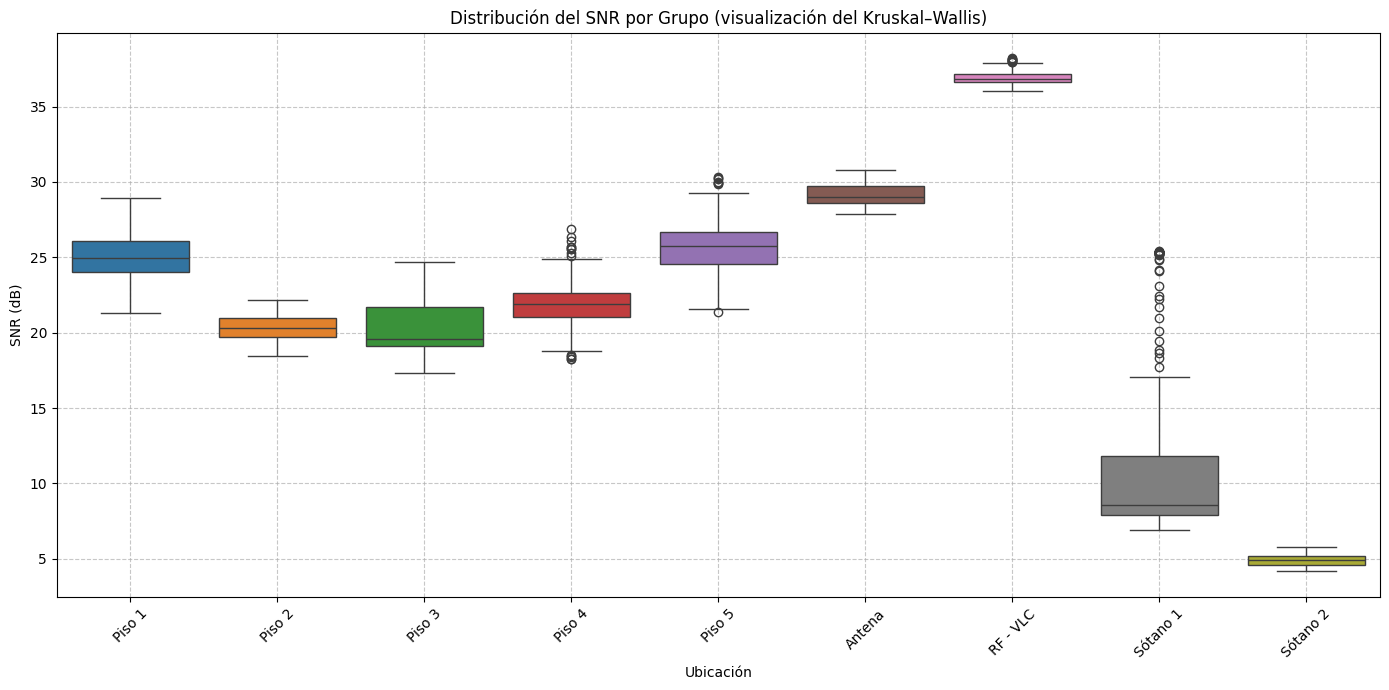

In [12]:
groups = [group['SNR'].values for name, group in all_data.groupby('Source')]
kw_stat, kw_p = kruskal(*groups)
print('Kruskal-Wallis Test:')
print(f'  Estadístico H = {kw_stat:.4f}')
print(f'  p-value       = {kw_p:.4e}')
print(f'  Grados de libertad (k-1) = {len(groups) - 1}')

alpha = 0.05
if kw_p < alpha:
    print(f'\n  Decisión: p ≤ {alpha} ⇒ SE RECHAZA H0.')
    print('  Hay diferencias significativas entre al menos dos ubicaciones.')
else:
    print(f'\n  Decisión: p > {alpha} ⇒ NO se rechaza H0.')
    print('  No hay evidencia de diferencias significativas entre las ubicaciones.')

# Boxplot comparativo (visualización del Kruskal-Wallis)
plt.figure(figsize=(14, 7))
sns.boxplot(x='Source', y='SNR', data=all_data, palette='tab10')
plt.xticks(rotation=45)
plt.title('Distribución del SNR por Grupo (visualización del Kruskal–Wallis)')
plt.xlabel('Ubicación')
plt.ylabel('SNR (dB)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(images_path, 'kruskal_boxplot.png'), format='png', dpi=600, transparent=True)
plt.savefig(os.path.join(images_path, 'kruskal_boxplot.pdf'), format='pdf', dpi=600, transparent=True)
plt.show()

**Lectura del resultado.** Con $H \approx 1403.11$ (extremadamente alto frente al valor crítico $\chi^2_{8,\,0.05} \approx 15.51$) y $p \approx 1.20\times 10^{-297}$, **rechazamos $H_0$ con altísima confianza**: existen diferencias estadísticamente significativas entre las medianas de SNR de las 9 ubicaciones.

**Implicación:** la ubicación **sí** tiene un efecto medible y cuantificable sobre la SNR. La degradación reportada en la tesis no es ruido aleatorio — es un fenómeno físico que el test confirma estadísticamente.

> **Limitación de Kruskal–Wallis:** la prueba indica que *al menos uno* de los grupos difiere, la inspección visual del violin plot (Sec. 3) y la lectura directa de la Tabla 4.1 lo comprueban: el contraste **Sótano 1 dinámico vs. Sótano 2 estable** y la jerarquía **Antena Yagi → Pisos → Sótanos → RF–VLC** son visualmente evidentes.

## 8. Conclusión estadística

| Pregunta | Respuesta basada en los tests |
|---|---|
| ¿Los datos son normales? | **No** — Shapiro–Wilk: $W = 0.928$, $p \ll 0.05$ → rechazamos normalidad. |
| ¿Hay diferencias significativas entre ubicaciones? | **Sí** — Kruskal–Wallis: $H = 1403.11$, $p = 1.20\times 10^{-297}$ → rechazamos igualdad de medianas. |
| ¿Qué prueba se eligió y por qué? | Kruskal–Wallis, porque tenemos $k>2$ grupos, los datos no son normales, las muestras no son pareadas. Camino validado por el árbol de Marusteri & Bacarea (2010). |
| ¿Qué implica para la tesis? | La degradación SNR observada en la Tabla 4.1 es un **fenómeno estadísticamente significativo**, no aleatorio. Justifica empíricamente la motivación de proponer un sistema híbrido RF–VLC para mitigar la no-uniformidad indoor. |

## 9. Archivos generados en `Study_images/`

In [13]:
generated = sorted(os.listdir(images_path))
print(f'Total de archivos generados: {len(generated)}\n')
for f in generated:
    full = os.path.join(images_path, f)
    size_kb = os.path.getsize(full) / 1024
    print(f'  - {f}  ({size_kb:.1f} KB)')

Total de archivos generados: 9

  - histogramIET.pdf  (23.5 KB)
  - histogramIET.png  (599.9 KB)
  - kruskal_boxplot.pdf  (18.6 KB)
  - kruskal_boxplot.png  (358.5 KB)
  - scatterplotIET.pdf  (27.6 KB)
  - scatterplotIET.png  (2641.8 KB)
  - statistics.csv  (1.4 KB)
  - violin_plotIET.pdf  (34.4 KB)
  - violin_plotIET.png  (839.6 KB)
